In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    ConfusionMatrixDisplay,
)

In [2]:
# берем датасет и отделяем переменные
# X=features, y=target
heart_failure = pd.read_csv('data/HeartFailureDataset.csv')
heart_failure_features = heart_failure.copy().drop(["id", "cardio"], axis=1)
heart_failure_target = heart_failure["cardio"]

print('\n \n -- Признаки --')
print(heart_failure_features.head())

print('\n \n -- Целевая переменная --')
print(heart_failure_target.head())

X_train, X_test, y_train, y_test = train_test_split(
    heart_failure_features,
    heart_failure_target,
    test_size=0.3,
    stratify=heart_failure_target,
    random_state=42,
)



 
 -- Признаки --
     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168      62    110     80            1     1      0   
1  20228       1     156      85    140     90            3     1      0   
2  18857       1     165      64    130     70            3     1      0   
3  17623       2     169      82    150    100            1     1      0   
4  17474       1     156      56    100     60            1     1      0   

   alco  active  
0     0       1  
1     0       1  
2     0       0  
3     0       1  
4     0       0  

 
 -- Целевая переменная --
0    0
1    1
2    1
3    1
4    0
Name: cardio, dtype: int64


In [3]:
print('--' * 45) # проверяем все данные в выборке
print('\n \n -- Обучающая выборка --')
print(f'Ожидаемое количество строк: {int(heart_failure.shape[0] * 0.7):,}')
print(f'Количество строк в X_train: {X_train.shape[0]:,}')
print(f'Количество строк в y_train: {y_train.shape[0]:,}')

print('\n \n -- Тестовая выборка --')
print(f'Ожидаемое количество строк: {int(heart_failure.shape[0] * 0.3):,}')
print(f'Количество строк в X_test: {X_test.shape[0]:,}')
print(f'Количество строк в y_test: {y_test.shape[0]:,}')

------------------------------------------------------------------------------------------

 
 -- Обучающая выборка --
Ожидаемое количество строк: 49,000
Количество строк в X_train: 49,000
Количество строк в y_train: 49,000

 
 -- Тестовая выборка --
Ожидаемое количество строк: 21,000
Количество строк в X_test: 21,000
Количество строк в y_test: 21,000


<h4>Standard Scaler</h4>

In [4]:
# Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3>KNN (K=5)</h3>

In [7]:
# KNN
# берем K=5, мы учитываем 5 ближайших соседей
knn_5_classifier = KNeighborsClassifier(n_neighbors=5)
knn_5_classifier.fit(X_train_scaled, y_train)
knn_5_predictions = knn_5_classifier.predict(X_test_scaled)

cm5 = confusion_matrix(y_test, knn_5_predictions)
accuracy5 = accuracy_score(y_test, knn_5_predictions)
recall5 = recall_score(y_test, knn_5_predictions)
precision5 = precision_score(y_test, knn_5_predictions)
f1_5 = f1_score(y_test, knn_5_predictions)

print('\n')
print('--' * 45)
print('Метрики для K=5')
print(f'Accuracy: {accuracy5:.4f}')
print(f'Recall: {recall5:.4f}')
print(f'Precision: {precision5:.4f}')
print(f'F1: {f1_5:.4f}')



------------------------------------------------------------------------------------------
Метрики для K=5
Accuracy: 0.6401
Recall: 0.6175
Precision: 0.6465
F1: 0.6317


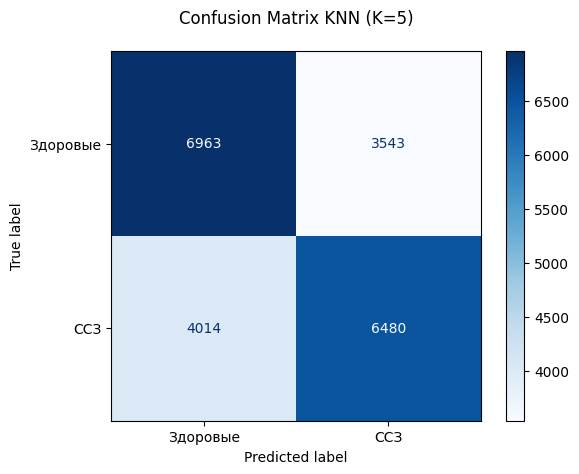

In [8]:
disp5 = ConfusionMatrixDisplay(
    confusion_matrix=cm5, display_labels=['Здоровые', 'ССЗ']
)
disp5.plot(cmap='Blues')
plt.title('Confusion Matrix KNN (K=5)', pad=20)
plt.show()

# обучаем KNN с K=9 и делаем предсказания на тестовой выборке
knn_9_classifier = KNeighborsClassifier(n_neighbors=9)
knn_9_classifier.fit(X_train_scaled, y_train)
knn_9_predictions = knn_9_classifier.predict(X_test_scaled)

<h3>KNN (K=9)</h3>

In [9]:
# оцениваем модель KNN с K=9
cm9 = confusion_matrix(y_test, knn_9_predictions)
accuracy9 = accuracy_score(y_test, knn_9_predictions)
recall9 = recall_score(y_test, knn_9_predictions)
precision9 = precision_score(y_test, knn_9_predictions)
f1_9 = f1_score(y_test, knn_9_predictions)

print('\n')
print('--' * 45)
print('Метрики для K=9')
print(f'Accuracy: {accuracy9:.4f}')
print(f'Recall: {recall9:.4f}')
print(f'Precision: {precision9:.4f}')
print(f'F1: {f1_9:.4f}')



------------------------------------------------------------------------------------------
Метрики для K=9
Accuracy: 0.6468
Recall: 0.6210
Precision: 0.6545
F1: 0.6373


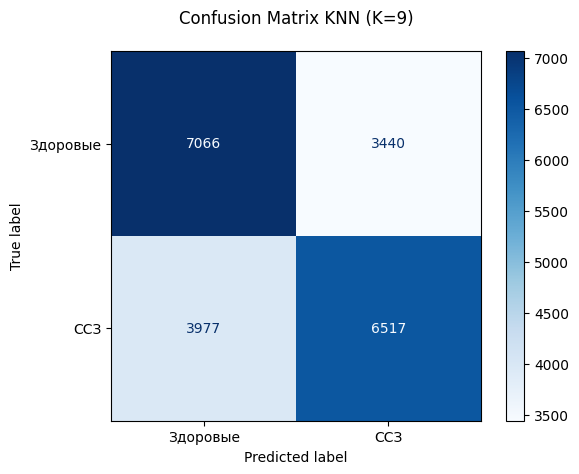

In [10]:
disp9 = ConfusionMatrixDisplay(
    confusion_matrix=cm9, display_labels=['Здоровые', 'ССЗ']
)
disp9.plot(cmap='Blues')
plt.title('Confusion Matrix KNN (K=9)', pad=20)
plt.show()

In [11]:
comparison_table = pd.DataFrame(
    {
        'KNN (K=5)': [
            accuracy5,
            recall5,
            precision5,
            f1_5
        ],
        'KNN (K=9)': [
            accuracy9,
            recall9,
            precision9,
            f1_9
        ]
    }, index=['Accuracy', 'Recall', 'Precision', 'F1 Score'])


comparison_table['Change'] = comparison_table['KNN (K=9)'] - comparison_table['KNN (K=5)']
comparison_table = comparison_table * 100
comparison_table = comparison_table.round(1)
comparison_table = comparison_table.astype(str) + '%'
comparison_table['Change'] = comparison_table['Change'].apply(
    lambda x: f'+{x}' if not x.startswith('-') else x

)

fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=comparison_table.values,
    colLabels=comparison_table.columns,
    rowLabels=comparison_table.index,
    loc='center'
)

table.scale(1.2, 1.5)
plt.close()

print('\n')
print('--' * 45)
print(comparison_table)




------------------------------------------------------------------------------------------
          KNN (K=5) KNN (K=9) Change
Accuracy      64.0%     64.7%  +0.7%
Recall        61.7%     62.1%  +0.4%
Precision     64.7%     65.5%  +0.8%
F1 Score      63.2%     63.7%  +0.6%


<h3>Logistic Regression</h3>

In [12]:
#Logistic Regression
# обучаем LR, делаем предсказания на тестовой выборке
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train_scaled, y_train)
lr_predictions = lr_classifier.predict(X_test_scaled)

# оцениваем модель LR
lr_cm = confusion_matrix(y_test, lr_predictions)
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

In [13]:
print('\n')
print('--' * 45)
print('Метрики для Logistic Regression')
print(f'Accuracy: {lr_accuracy:.4f}')
print(f'Recall: {lr_recall:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'F1: {lr_f1:.4f}')



------------------------------------------------------------------------------------------
Метрики для Logistic Regression
Accuracy: 0.7119
Recall: 0.6720
Precision: 0.7299
F1: 0.6998


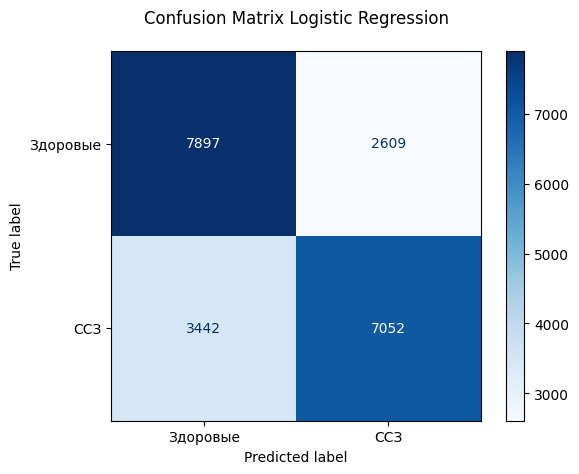

In [14]:
disp_lr = ConfusionMatrixDisplay(
        confusion_matrix=lr_cm, display_labels=['Здоровые', 'ССЗ'])
disp_lr.plot(cmap='Blues')
plt.title('Confusion Matrix Logistic Regression', pad=20)
plt.show()

In [15]:
comparison_lr_knn_9 = pd.DataFrame(
    {"KNN (K=9)": [
        accuracy5,
        recall5,
        precision5,
        f1_5
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_recall,
        lr_precision,
        lr_f1
    ]},  index=['Accuracy', 'Recall', 'Precision', 'F1 Score'])

comparison_lr_knn_9['Change'] = comparison_lr_knn_9['Logistic Regression'] - comparison_lr_knn_9['KNN (K=9)']
comparison_lr_knn_9 = comparison_lr_knn_9 * 100
comparison_lr_knn_9 = comparison_lr_knn_9.round(1)
comparison_lr_knn_9 = comparison_lr_knn_9.astype(str) + '%'
comparison_lr_knn_9['Change'] = comparison_lr_knn_9['Change'].apply(
    lambda x: f'+{x}' if not x.startswith('-') else x
)
print('\n')
print(comparison_lr_knn_9)

fig, ax = plt.subplots()
ax.axis('off')

table_lr = ax.table(
    cellText=comparison_lr_knn_9.values,
    colLabels=comparison_lr_knn_9.columns,
    rowLabels=comparison_lr_knn_9.index,
    loc='center'
)

table_lr.scale(1.2, 1.5)
plt.close()



          KNN (K=9) Logistic Regression Change
Accuracy      64.0%               71.2%  +7.2%
Recall        61.7%               67.2%  +5.5%
Precision     64.7%               73.0%  +8.3%
F1 Score      63.2%               70.0%  +6.8%
